In [1]:
from copy import copy
from collections import defaultdict, Counter
import pathlib
from tqdm import tqdm
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression, \
                                 LinearRegression
from sklearn.metrics import precision_recall_fscore_support

from pprint import pprint

# import conllu
from scipy.sparse import csr_matrix
import pymorphy3

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from umap.umap_ import UMAP

In [2]:
morph = pymorphy3.MorphAnalyzer()
morpho_cashe = defaultdict(str)

# Расчёт статистики всех связей в фрагменте книги с учётом их направления.
def calc_syntax_stat(book):
    con_stat = defaultdict(int)
    overall = 0
    for sentence in book:
        overall += len(sentence)
        for child_position, word in enumerate(sentence):
            if word['head'] is None:
                continue
            parent_position = word['head'] - 1
            if parent_position == -1:
                continue
            if parent_position > child_position:
                d = '<-'
            else:
                d = '->'
            con_stat[f"({sentence[parent_position]['upos']}, {d}, {word['upos']}, {word['deprel']})"] += 1

    for key in con_stat.keys():
        con_stat[key] /= overall
    return con_stat

def calc_homonymy_stat(book):
    con_stat = defaultdict(int)
    overall = 0

    for sentence in book:
        overall += len(sentence)
        for word in sentence:
            if morpho_cashe[word['form']] != '':
                con_stat[morpho_cashe[word['form']]] += 1
            else:
                res = morph.parse(word['form'])
                nfs = list(set(a.normal_form for a in res))
                poses = list(set(a.tag.POS for a in res))

                if len(nfs) > 1: # Ambigous by lemma
                    if len(poses) > 1:
                        con_stat['pos_lemma'] += 1
                        morpho_cashe[word['form']] = 'pos_lemma'
                    else:
                        con_stat['lemma'] += 1
                        morpho_cashe[word['form']] = 'lemma'
                else:
                    if len(poses) > 1:
                        con_stat['pos'] += 1
                        morpho_cashe[word['form']] = 'pos'
                    else:
                        if len(res) > 1:
                            con_stat['feat'] += 1
                            morpho_cashe[word['form']] = 'feat'
                        else:
                            con_stat['unambig'] += 1
                            morpho_cashe[word['form']] = 'unambig'


    for key in con_stat.keys():
        con_stat[key] /= overall
    return con_stat

# service_poses = {'ADVB', 'NPRO', 'PRED', 'PREP', 'CONJ', 'PRCL', 'INTJ'}
service_poses = {'ADV', 'PRON', 'ADP', 'CCONJ', 'SCONJ', 'PART', 'DET'}

def calc_service_stat(book):
    con_stat = defaultdict(int)
    overall = 0

    for sentence in book:
        overall += len(sentence)
        for word in sentence:
            if word['upos'] in service_poses:
                con_stat[f'{word["lemma"]}_{word["upos"]}'] +=1

    for key in con_stat.keys():
        con_stat[key] /= overall
    return con_stat

def calc_char_stat(book):
    con_stat = defaultdict(int)
    overall = 0

    for sentence in book:
        overall += len(sentence)
        for word in sentence:
            res = Counter(word['form'])
            for c, f in res.items():
                con_stat[c] += f

    for key in con_stat.keys():
        con_stat[key] /= overall
    return con_stat

In [3]:
class CONLLUParser:
    '''
    Собственный класс для разбора CONLLU файлов.
    Потому что стандартный какой-то очень медленный.
    '''
    sentences: list # Список предложения текста, содержащих синтаксическую информацию.
    texts: list # Список предложений в текстовой форме.

    def __init__(self):
        self.sentences = []
        self.texts = []

    # Превращает кортеж в словарь слова.
    def __make_wordform(self, word):
        res = dict()
        res['id'] = int(word[0])
        res['form'] = word[1]
        res['lemma'] = word[2]
        res['upos'] = word[3]
        res['head'] = int(word[6])
        res['deprel'] = word[7]
        return res

    def __read_sentence(self, lines, pos):
        ''' Возвращает предложение из списка строк lines, записанных в формате UD.
            Предложение находится начиная со строки с номером pos.
        '''
        sent = []
        text = ""
        while pos < len(lines) and lines[pos] != '' and lines[pos] != '\n':
            try:
              if lines[pos][0] != '#':
                  sent.append(self.__make_wordform(lines[pos][:-2].split("\t")))
              elif lines[pos].startswith('# text = '):
                  text = lines[pos][9:]
            except:
              print(f"Exception: {lines[pos]}")
            pos += 1
        pos += 1
        return sent, text, pos

    # Считывает книгу в conllu из списка строк.
    def parse_conllu_lines(self, lines):
        del self.sentences
        del self.texts
        self.sentences = []
        self.texts = []
        pos = 0
        while pos < len(lines):
            sent, text, pos = self.__read_sentence(lines, pos)
            self.sentences.append(sent)
            self.texts.append(text)

    # Считывает книгу в conllu из файла.
    def parse_conllu_file(self, filename):
        with open(filename, "rt", encoding='utf-8') as book_file:
            lines = book_file.readlines()
            self.parse_conllu_lines(lines)
            del lines

In [4]:
class WriterStorage:
    '''
        Класс служит для расчёта показателей, по коорым будет определяться авторство.
      Из модуля calc_stat_vectors выгружаются функции, которые считают параметры:
      частоты по синтаксису, грамматической неоднозначности, символам, служебным частям речи.
      Он умеет сеарилизовать себя в json, потому что когда считаешь фрагментами по 10 предложений,
      по большой коллекции тебе мало 64Г оперативки.
    '''

    # Описание свойств
    book_authors: list # Список имён авторов по книгам.
    book_names: list # Список названий книг.
    authors_id: dict # Словарь соответствий фамилии автора и его идентификатора.
    book_author_id: list # Список идентификаторов авторов по книгам.
    parts_author_id: list # Список идентификаторов авторов по частям.
    book_no: list # Номер книги в списке.

    books_stat: list # Статистика по книгам в виде словаря.
    parts_stat: list # Статистика по частям в виде словаря.
    part_no: list # Номер части в книге.
    part_book_no: list # Номер книги соответствующей части.
    books_vect_dict: dict # Словарь признаков и их номеров в векторе по книгам в целом.
    books_vect: list # Векторы признаков по книгам в целом.
    parts_vect_dict: dict # Словарь признаков и их номеров в векторе по всем частям книг.
    parts_vect: list # Векторы признаков по частям книг.
    texts_by_parts: list # Тексты по частям.

    def __init__(self):
        self.book_names = []
        self.book_authors = []
        self.book_sentences = []
        self.authors_id = dict()

    # Словарь с функциями, коорые используются для расчёта. Ключ передается в функцию в качестве параметра.
    __func_correspondence  = {'syntax': calc_syntax_stat,
                              'service': calc_service_stat,
                              'homonymy': calc_homonymy_stat,
                              'char': calc_char_stat
                             }

    def calc_connections_distr(self, book, text, what='syntax', fragment_len = 100):
        '''
           Функция расчёта параметров для одной книги.
           book: Текст книги с синтаксической разметкой, разделенный на предложения.
           text: Текст книги, разделенный на предложения. Нужен, чтобы можно было посмореть где что.
           what: Какие параметры надо считать. Определяет какая функция расчёта параметров будет вызвана.
           fragment_len: Длина фрагментов, на кототрые надо делить.
           Возвращает синтаксически рамеченные предложения и текст книги, разделенные фрагменты.
           Если fragment_len = -1, возвращает книгу целиком.
        '''
        # Проверка, есть ли у нас такой ключ.
        if what not in WriterStorage.__func_correspondence.keys():
            raise Exception(f'We calculate statistics for the followig keys: '
                            f'{", ".join(WriterStorage.__func_correspondence.keys())}')

        # Расчёт статистики.
        # Определяем по какой функции ведётся расчёт.
        calc_connections_stat = WriterStorage.__func_correspondence[what]

        # -1 означает,что стаисика считаеттся для книги в целом.
        if fragment_len == -1:
            distr = calc_connections_stat(book)
            texts = [[text]]
        # В проивном случае надо разделить книгу на фрагменты.
        else:
            distr = []
            texts = []
            for i in range(0, len(book), fragment_len):
                # print(i, fragment_len)
                # print(book[i: i+fragment_len])
                distr.append(calc_connections_stat(book[i: i+fragment_len]))
                texts.append(text[i: i+fragment_len])
        return distr, texts

    def make_vector(self, data, keys):
        ''' Возвращает данные, собранные в виде словаря data в виде вектора,
            Соблюдая при этом порядок следования параметров, задаваемый при помощи keys.
        '''
        vect = np.zeros((len(keys)))
        for key, val in data.items():
            vect[keys[key]] = val
        return vect

    def vectorize_data(self, data):
        '''
        Векторизует данные из словаря data.
        Возвращает словарь признаков с номерами их позиций в векторе и сам вектор.
        '''
        data_dict = []
        for part in data:
            data_dict.extend(part.keys()) # data_dict |= set(part.keys())
        data_dict = list(set(data_dict))
        data_dict = {key:i for i, key in enumerate(data_dict)}

        # Теперь создаем разреженный массив с результирующими векторами.
        res_list = []
        rows = []
        cols = []
        for row_no, part in enumerate(data):
            res_list.extend(part.values())
            cols.extend([data_dict[key] for key in part.keys()])
            rows.extend([row_no for key in part.keys()])

        ret_data = csr_matrix((res_list, (rows, cols)), (len(data), len(data_dict))).toarray()

        # vects_a = []
        # for part in data:
        #     vects_a.append(self.make_vector(part, data_dict))
        return data_dict, ret_data

    def process_books(self, path, what='syntax', fragment_size=100):
        '''
        Функция обработки книг из каталога path по признакам, задаваемым параметром what.
        Режет текст на фрагменты размера fragment_size, если он равен -1, возвращает данные для книг целиком.
        '''
        parser = CONLLUParser() # Будет разбирать CONLLU.

        files2 = pathlib.Path(path).glob('*.conllu')
        self.books_stat = []
        self.parts_stat = []
        self.book_no = []
        self.part_no = []
        self.book_author_id = []
        self.parts_author_id = []
        self.authors_id = dict()
        self.part_book_no = []
        self.texts_by_parts = []
        self.fragment_size = fragment_size

        # Перебираем книги в CONLLU-формате.
        for i, file in enumerate(list(files2)):
            # Информация по книге. Выделяем из имени файла автора и название книги.
            # print(i, file.name)
            a = file.name.split("_")
            if a[0][-1] >= '0' and a[0][-1] <= '9':
                a[0] = a[0][:-1]
            self.book_authors.append(a[0])
            self.book_names.append(a[1][:-11])
            if a[0] not in self.authors_id.keys():
                auth_no = len(self.authors_id.keys())
                self.authors_id[a[0]] = auth_no
            else:
                auth_no = self.authors_id[a[0]]
            self.book_author_id.append(auth_no)
            self.book_no.append(i)
            print(i, a[0], a[1][:-11])

            # Читаем CONLLU.
            parser.parse_conllu_file(file.absolute())
            # book, text = parser.sentences, parser.texts
            # self.book_sentences.append(book)
            if fragment_size==-1:
                al, all_texts = self.calc_connections_distr(parser.sentences,  parser.texts, what, -1)
                self.books_stat.append(al)
            else:
                parts, parts_texts = self.calc_connections_distr(parser.sentences, parser.texts, what, fragment_size)
                # добавляем информацию и статисику по фрагментам.
                self.parts_stat.extend(parts)
                self.parts_author_id.extend([auth_no for part in parts])
                self.part_no.extend([p_n for p_n in range(len(parts))])
                self.part_book_no.extend([i for p_n in range(len(parts))])
                self.texts_by_parts.extend([t for t in parts_texts])

        # Векторизуем книги и фрагменты.
        if fragment_size == -1:
            d, v = self.vectorize_data(self.books_stat)
            self.books_vect_dict = d
            self.books_vect = v
        else:
            d, v = self.vectorize_data(self.parts_stat)
            self.parts_vect_dict = d
            self.parts_vect = v
        self.back_id = {i: a for a, i in self.authors_id.items()}

In [5]:
writers = WriterStorage()

writers.process_books('conllu_DeepPavlov', 'syntax', -1)

0 Abgaryan dalshe zhit
1 Abgaryan molchaie
2 Abgaryan 3apples
3 Abgaryan Fantastychysi
4 Abgaryan Jubileum
5 Abgaryan Ponaekhavshaya
6 Abgaryan Simon
7 Adamov Izgnanine vladyki
8 Adamov Pobediteli nedr
9 Adamov Tayna dvuh okeanov
10 Aksakov Vol1
11 Aksakov Vol2
12 Aksakov Vol3
13 Aksakov Vol4
14 Aksakov Vol5
15 AkuninBorisova Kreativschik
16 AkuninBrusnikin Bellona
17 AkuninBrusnikin Devyatny spas
18 AkuninBrusnikin Hero of another time
19 Akunin Almaznaya kolesnitsa 1
20 Akunin Almaznaya kolesnitsa 2
21 Akunin Azazel
22 Akunin Grom Pobedy
23 Akunin Leviafan
24 Akunin Lubovnik smerti
25 Akunin Nefritovye chetki
26 Akunin No West and East
27 Akunin Smert Ahillesa
28 Akunin Turetski gambit
29 Akunin World is theatre
30 Aldanov Armageddon
31 Aldanov Begstvo
32 Aldanov Bred
33 Aldanov Erfurtskoe svidanie
34 Aldanov Istoricheskie portrety
35 Aldanov Kartiny Oktyabrskogo perevorota
36 Aldanov Kluch
37 Aldanov Mogila voina
38 Aldanov Nachalo konca
39 Aldanov Ogon i dym
40 Aldanov Peschera
41 

#Переменные

In [6]:

#     book_authors: list # Список имён авторов по книгам.
#     book_names: list # Список названий книг.
#     authors_id: dict # Словарь соответствий фамилии автора и его идентификатора.
#     book_author_id: list # Список идентификаторов авторов по книгам.
#     parts_author_id: list # Список идентификаторов авторов по частям.

#     books_stat: list # Статистика по книгам в виде словаря.
#     parts_stat: list # Статистика по частям в виде словаря.
#     book_no: list # Номер книги в списке.
#     part_no: list # Номер части в книге.
#     books_vect_dict: dict # Словарь признаков и их номеров в векторе по книгам в целом.
#     books_vect: list # Векоры признаков по книгам в целом.
#     parts_vect_dict: dict # Словарь признаков и их номеров в векторе по всем частям книг.
#     parts_vect: list # Векоры признаков по частям книг.


# parts_vect_np = np.array(writers.parts_vect)
# parts_author_id_np = np.array(writers.parts_author_id)

books_vect_np = np.array(writers.books_vect)
books_author_id_np = np.array(writers.book_author_id)


In [7]:
book_id_to_name = {k: v for k,v in enumerate(writers.book_names)}

In [8]:
book_id_to_name[0]

'dalshe zhit'

In [9]:
feature_names = [k for k, v in writers.books_vect_dict.items()]
features = [v for k,v in writers.books_vect_dict.items()]

In [10]:
books_features = np.array(writers.books_vect)
book_author_ids = np.array(writers.book_author_id)
author_ids = np.array(list(writers.authors_id.values()))
author_names = np.array(list(writers.authors_id.keys()))
author_id_to_name = {v: k for k, v in writers.authors_id.items()}


In [11]:
author_feature_means = []

for author_id in author_ids:
    author_mask = (book_author_ids == author_id)
    author_feature_means.append(np.mean(books_features[author_mask], axis=0))

feature_authors = np.array(author_feature_means)

In [12]:
def normalize_array(data):
    for i, array in enumerate(data):
        sum = np.sum(array)
        data[i] = array / sum
    return data

In [13]:
feature_authors = normalize_array(feature_authors)

#Фильтр фичей по пунктуации и частоте

In [73]:
#без фильтра пунктуации
author_filteredfeats = defaultdict(dict)
feature_authors = np.array(feature_authors)
counter_features = Counter()

for author in feature_authors:
    for i, feature in enumerate(author):
        if feature >= 0.00005:
          counter_features[i] += 1
        else:
          counter_features[i] += 0

filter_mask = [count > 1 for count in counter_features.values()]

filtered_feature_authors = feature_authors[:, filter_mask]

filtered_feature_names = np.array(feature_names)[filter_mask]

filtered_feature_authors = normalize_array(filtered_feature_authors)

n_authors = len(filtered_feature_authors)
n_features = filtered_feature_authors.shape[1]

doc_freq = np.zeros(n_features)
for i in range(n_authors):
    doc_freq += (filtered_feature_authors[i] >= 0.0005).astype(int)

min_freq = 1e-8
idf = np.log(n_authors / (doc_freq + min_freq))

for author_id, author_vect in enumerate(tqdm(filtered_feature_authors)):
    if author_vect.max() > 0:
        tf_norm = author_vect / author_vect.max()
    else:
        tf_norm = author_vect.copy()

    tf_idf = tf_norm * idf

    k = 2000
    top_k_indices = np.argsort(tf_idf)[-k:][::-1]
    top_tfidf = sorted(tf_idf)[-k:][::-1]

    freq_features = top_k_indices.tolist()

    author_filteredfeats[author_id_to_name[author_id]]['features']= freq_features
    author_filteredfeats[author_id_to_name[author_id]]['stats']= top_tfidf

100%|██████████| 124/124 [00:00<00:00, 588.60it/s]


In [74]:
books_vect_np = np.array(writers.books_vect)
classif_all_feat_select = defaultdict(dict)
author_quality = defaultdict(dict)
books_x = books_vect_np.shape[0]
how_separate = 'syntax'
part_len_sep = 'whole'
passed = 0
from sklearn.feature_selection import mutual_info_classif

print(f"{'name':18},{'precision':>10},{'recall':>10},{'support':>10}")
with open(f"writers_{how_separate}_{part_len_sep}.csv", "at") as out_file:
    out_file.write(f"{'name':18};{'precision':>10};{'recall':>10};{'f-score':>10};{'support':>10}\n")

for cur_author_name, cur_author_id in writers.authors_id.items():
    print(cur_author_name, end='\r')
    book_no = books_author_id_np[books_author_id_np==cur_author_id].shape[0]
    books_vect_np_author = books_vect_np[:, author_filteredfeats[cur_author_name]['features']]
    labels_orig = np.zeros((books_x))
    labels_orig[books_author_id_np==cur_author_id] = 1

    labels = np.zeros((books_x + book_no))
    labels[:labels_orig.shape[0]][books_author_id_np==cur_author_id] = 1
    labels[books_x:] = 1

    data = np.zeros((books_x + book_no, books_vect_np_author.shape[1]))
    data[:books_x, :] = books_vect_np_author

    data[books_x:books_x+book_no, :] = books_vect_np_author[books_author_id_np==cur_author_id]

    model = LinearRegression()
    model.fit(data, labels)

    y_hat = model.predict(books_vect_np_author)

    y_hat[y_hat>0.5] = 1
    y_hat[y_hat<=0.5] = 0

    res = precision_recall_fscore_support(labels_orig, y_hat, zero_division=0.0)
    feature_importance = model.coef_

    info_gain = mutual_info_classif(data, labels)

    author_mask = books_author_id_np == cur_author_id
    others_mask = ~author_mask

    author_data = books_vect_np_author[author_mask]
    others_data = books_vect_np_author[others_mask]

    mean_author = np.mean(author_data, axis=0)
    mean_others = np.mean(others_data, axis=0)

    std_all = np.std(books_vect_np_author, axis=0)
    std_all[std_all == 0] = 1e-8

    z_score = (mean_author - mean_others) / std_all

    tf_idf = author_filteredfeats[cur_author_name]['stats']
    feature_stats = counter_features 
    classif_all_feat_select[cur_author_id]['feature_importance'] = feature_importance
    classif_all_feat_select[cur_author_id]['z_score'] = z_score
    classif_all_feat_select[cur_author_id]['info_gain'] = info_gain
    classif_all_feat_select[cur_author_id]['feature_stats'] = feature_stats
    classif_all_feat_select[cur_author_id]['tfidf'] = tf_idf


    classif_all_feat_select[cur_author_id]['features_feature_importance'] = [i for i in np.argsort(feature_importance)[::-1]]
    classif_all_feat_select[cur_author_id]['features_z_score'] = [i for i in np.argsort(z_score)[::-1]]
    classif_all_feat_select[cur_author_id]['features_info_gain'] = [i for i in np.argsort(info_gain)[::-1]]


    author_quality[cur_author_id]['support'] = res[3][1]
    author_quality[cur_author_id]['precision'] = res[0][1]
    author_quality[cur_author_id]['recall'] = res[1][1]

    with open(f"writers_{how_separate}_{part_len_sep}.csv", "at") as out_file:
      out_file.write(f"{cur_author_name};{res[0][1]};{res[1][1]};{2*res[0][1]*res[1][1]/(res[1][1] + res[0][1])};{res[3][1]}\n")

    if res[0][1]!=0.0:
      passed +=1
      print(f"{cur_author_name:18},{res[0][1]:10.3},{res[1][1]:10.3}, {res[3][1]:>4} / {res[3][0]}")
    else:
      print(f"-------{cur_author_name:18},{res[0][1]:10.3},{res[1][1]:10.3}, {res[3][1]:>4} / {res[3][0]}")

print(passed, '/', len(writers.authors_id))


name              , precision,    recall,   support
Abgaryan          ,       1.0,       1.0,    7 / 591
Adamov            ,       1.0,       1.0,    3 / 595
Aksakov           ,       1.0,       1.0,    5 / 593
AkuninBorisova    ,       1.0,       1.0,    1 / 597
AkuninBrusnikin   ,       1.0,       1.0,    3 / 595
Akunin            ,       1.0,       1.0,   11 / 587
Aldanov           ,       1.0,       1.0,   20 / 578
Aleshkovsky       ,       1.0,       1.0,    6 / 592
Alexander Hofman  ,       1.0,       1.0,    1 / 597
Astafiev          ,       1.0,       1.0,    4 / 594
Bakhtin           ,       1.0,       1.0,    4 / 594
Barinova          ,       1.0,       1.0,    1 / 597
bashinform 202    ,       1.0,       1.0,    1 / 597
Belyaev           ,       1.0,       1.0,   10 / 588
Belyanin          ,       1.0,       1.0,    8 / 590
Bobkova           ,       1.0,       1.0,    1 / 597
BonchOsmolovskaya ,       1.0,       1.0,    4 / 594
Brustein          ,       1.0,       1.0,    7 

In [75]:
def get_df(selec_type):
    _rows = []
    for author, info in classif_all_feat_select.items():
        row = {
            'author_id': author,
            selec_type: info[selec_type],
            'features': info[f'features_{selec_type}'],
            'feature_stats': info['feature_stats'],
            'tfidf': info['tfidf']
        }
        _rows.append(row)
    return pd.DataFrame(_rows)

In [94]:
classification_feature_importance_df = get_df('feature_importance')
classification_z_score_df = get_df('z_score')
classification_info_gain_df = get_df('info_gain')

In [103]:
classification_feature_importance_df5 = get_df('feature_importance')
classification_z_score_df5 = get_df('z_score')
classification_info_gain_df5 = get_df('info_gain')

In [95]:
def get_n_features_sorted(df, selec_type, n):
    feature_names_np = np.array(feature_names)
    for idx, row in df.iterrows():
        features = row['features']
        selec_type_row = row[selec_type]
        author_id = row['author_id']
        stats = row['feature_stats']
        tfidf = row['tfidf']

        indexed_ = []
        for i, value in enumerate(selec_type_row):
            indexed_.append((value, i))

        sorted_indexed_ = sorted(indexed_, key=lambda item: item[0], reverse=True)

        new_imp = [item[0] for item in sorted_indexed_ if feature_authors[author_id][item[1]] > 0]
        sorted_features = [item[1] for item in sorted_indexed_ if feature_authors[author_id][item[1]] > 0]
        sorted_stats = [stats[i] for i in features]
        sorted_tfidf = [tfidf[i] for i in features]
        df.at[idx, 'author'] = author_id_to_name[author_id]

        df.at[idx, selec_type] = new_imp[:n]
        df.at[idx, 'feature_stats'] = sorted_stats[:n]
        df.at[idx, 'tfidf'] = sorted_tfidf[:n]
        df.at[idx, 'features'] = sorted_features[:n]

        df.at[idx, 'feature_names'] = feature_names_np[np.array(sorted_features)[:n]]
    return df

In [96]:
feature_importance_top_feats = get_n_features_sorted(classification_feature_importance_df, 'feature_importance', 500)
z_score_top_feats = get_n_features_sorted(classification_z_score_df, 'z_score', 500)
info_gain_top_feats = get_n_features_sorted(classification_info_gain_df, 'info_gain', 500)

In [104]:
feature_importance_top_feats5 = get_n_features_sorted(classification_feature_importance_df5, 'feature_importance', 5)
z_score_top_feats5 = get_n_features_sorted(classification_z_score_df5, 'z_score', 5)
info_gain_top_feats5 = get_n_features_sorted(classification_info_gain_df5, 'info_gain', 5)

In [105]:
feature_importance_top_feats5.to_csv('filterednew-whole_featimp5.csv')
z_score_top_feats5.to_csv('filterednew-whole_zscore5.csv')
info_gain_top_feats5.to_csv('filterednew-whole_infogain5.csv')

In [97]:
def get_results(df, selec_type):
  author_topfeats = defaultdict(dict)
  for i, row in df.iterrows():
    author_topfeats[row['author']][selec_type] = row['features']
  books_vect_np = np.array(writers.books_vect)
  author_quality = defaultdict(dict)
  books_x = books_vect_np.shape[0]
  how_separate = 'syntax'
  part_len_sep = 'whole'
  passed = 0

  print(f"{'name':18},{'precision':>10},{'recall':>10},{'support':>10}")
  with open(f"writers_{how_separate}_{part_len_sep}_{selec_type}.csv", "at") as out_file:
      out_file.write(f"{'name':18};{'precision':>10};{'recall':>10};{'f-score':>10};{'support':>10}\n")

  for cur_author_name, cur_author_id in writers.authors_id.items():
      print(cur_author_name, end='\r')
      book_no = books_author_id_np[books_author_id_np==cur_author_id].shape[0]
      books_vect_np_author = books_vect_np[:, author_topfeats[cur_author_name][selec_type]]
      labels_orig = np.zeros((books_x))
      labels_orig[books_author_id_np==cur_author_id] = 1

      labels = np.zeros((books_x + book_no))
      labels[:labels_orig.shape[0]][books_author_id_np==cur_author_id] = 1
      labels[books_x:] = 1

      data = np.zeros((books_x + book_no, books_vect_np_author.shape[1]))
      data[:books_x, :] = books_vect_np_author

      data[books_x:books_x+book_no, :] = books_vect_np_author[books_author_id_np==cur_author_id]

      model = LinearRegression()
      model.fit(data, labels)

      y_hat = model.predict(books_vect_np_author)

      y_hat[y_hat>0.5] = 1
      y_hat[y_hat<=0.5] = 0

      res = precision_recall_fscore_support(labels_orig, y_hat, zero_division=0.0)

      author_quality[cur_author_id]['support'] = res[3][1]
      author_quality[cur_author_id]['precision'] = res[0][1]
      author_quality[cur_author_id]['recall'] = res[1][1]

      with open(f"writers_{how_separate}_{part_len_sep}_{selec_type}.csv", "at") as out_file:
        out_file.write(f"{cur_author_name};{res[0][1]};{res[1][1]};{2*res[0][1]*res[1][1]/(res[1][1] + res[0][1] + 1e-10)};{res[3][1]}\n")

      if res[0][1]!=0.0:
        passed +=1
        print(f"{cur_author_name:18},{res[0][1]:10.3},{res[1][1]:10.3}, {res[3][1]:>4} / {res[3][0]}")
      else:
        print(f"-------{cur_author_name:18},{res[0][1]:10.3},{res[1][1]:10.3}, {res[3][1]:>4} / {res[3][0]}")

  print(passed, '/', len(writers.authors_id))
  return author_quality


In [98]:
author_quality_feat_imp = get_results(feature_importance_top_feats, 'feature_importance')

name              , precision,    recall,   support
Abgaryan          ,       1.0,       1.0,    7 / 591
Adamov            ,       1.0,       1.0,    3 / 595
Aksakov           ,       1.0,       1.0,    5 / 593
AkuninBorisova    ,       1.0,       1.0,    1 / 597
AkuninBrusnikin   ,       1.0,       1.0,    3 / 595
Akunin            ,       1.0,       1.0,   11 / 587
Aldanov           ,       1.0,       1.0,   20 / 578
Aleshkovsky       ,       1.0,       1.0,    6 / 592
Alexander Hofman  ,       1.0,       1.0,    1 / 597
Astafiev          ,       1.0,       1.0,    4 / 594
Bakhtin           ,       1.0,       1.0,    4 / 594
Barinova          ,       1.0,       1.0,    1 / 597
bashinform 202    ,       1.0,       1.0,    1 / 597
Belyaev           ,       1.0,       1.0,   10 / 588
Belyanin          ,       1.0,       1.0,    8 / 590
Bobkova           ,       1.0,       1.0,    1 / 597
BonchOsmolovskaya ,       1.0,       1.0,    4 / 594
Brustein          ,       1.0,       1.0,    7 

In [99]:
author_quality_z_score = get_results(z_score_top_feats, 'z_score')

name              , precision,    recall,   support
Abgaryan          ,       1.0,       1.0,    7 / 591
Adamov            ,       1.0,       1.0,    3 / 595
Aksakov           ,       1.0,       1.0,    5 / 593
AkuninBorisova    ,       1.0,       1.0,    1 / 597
AkuninBrusnikin   ,       1.0,       1.0,    3 / 595
Akunin            ,       1.0,       1.0,   11 / 587
Aldanov           ,       1.0,       1.0,   20 / 578
Aleshkovsky       ,       1.0,       1.0,    6 / 592
Alexander Hofman  ,       1.0,       1.0,    1 / 597
Astafiev          ,       1.0,       1.0,    4 / 594
Bakhtin           ,       1.0,       1.0,    4 / 594
Barinova          ,       1.0,       1.0,    1 / 597
bashinform 202    ,       1.0,       1.0,    1 / 597
Belyaev           ,       1.0,       1.0,   10 / 588
Belyanin          ,       1.0,       1.0,    8 / 590
Bobkova           ,       1.0,       1.0,    1 / 597
BonchOsmolovskaya ,       1.0,       1.0,    4 / 594
Brustein          ,       1.0,       1.0,    7 

In [100]:
author_quality_info_gain = get_results(info_gain_top_feats, 'info_gain')

name              , precision,    recall,   support
Abgaryan          ,       1.0,       1.0,    7 / 591
Adamov            ,       1.0,       1.0,    3 / 595
Aksakov           ,       1.0,       1.0,    5 / 593
AkuninBorisova    ,       1.0,       1.0,    1 / 597
AkuninBrusnikin   ,       1.0,       1.0,    3 / 595
Akunin            ,       1.0,       1.0,   11 / 587
Aldanov           ,       1.0,       1.0,   20 / 578
Aleshkovsky       ,       1.0,       1.0,    6 / 592
Alexander Hofman  ,       1.0,       1.0,    1 / 597
Astafiev          ,       1.0,       1.0,    4 / 594
Bakhtin           ,       1.0,       1.0,    4 / 594
Barinova          ,       1.0,       1.0,    1 / 597
bashinform 202    ,       1.0,       1.0,    1 / 597
Belyaev           ,       1.0,       1.0,   10 / 588
Belyanin          ,       1.0,       1.0,    8 / 590
Bobkova           ,       1.0,       1.0,    1 / 597
BonchOsmolovskaya ,       1.0,       1.0,    4 / 594
Brustein          ,       1.0,       1.0,    7 

In [101]:
import matplotlib.pyplot as plt

def get_visual_quality(df, selec_type):
    supports = []
    precisions = []
    recalls = []

    for author_id, metrics in df.items():
        supports.append(metrics['support'])
        precisions.append(metrics['precision'])
        recalls.append(metrics['recall'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Precision and Recall with punct ({selec_type})')
    ax1.scatter(supports, precisions, alpha=0.6)
    ax1.set_xlabel('Support')
    ax1.set_ylabel('Precision')
    ax1.grid(True, alpha=0.3)

    ax2.scatter(supports, recalls, alpha=0.6)
    ax2.set_xlabel('Support')
    ax2.set_ylabel('Recall')
    ax2.grid(True, alpha=0.3)


    plt.tight_layout()
    plt.show()


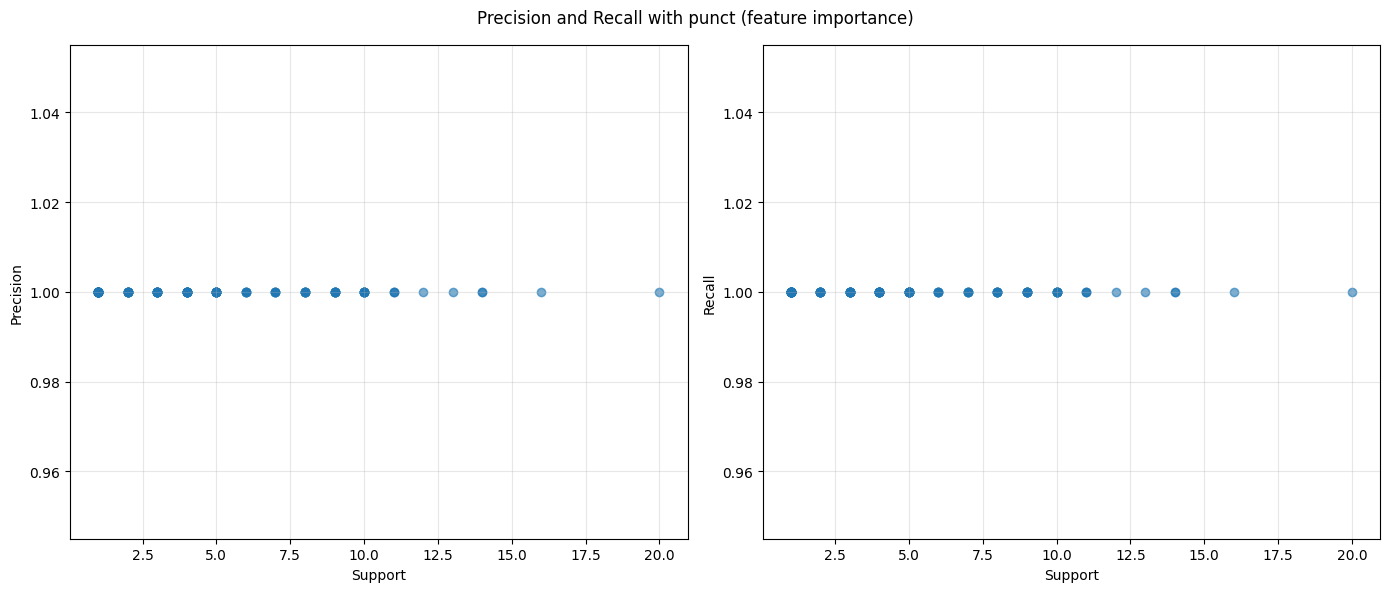

In [102]:
get_visual_quality(author_quality_feat_imp, 'feature importance')

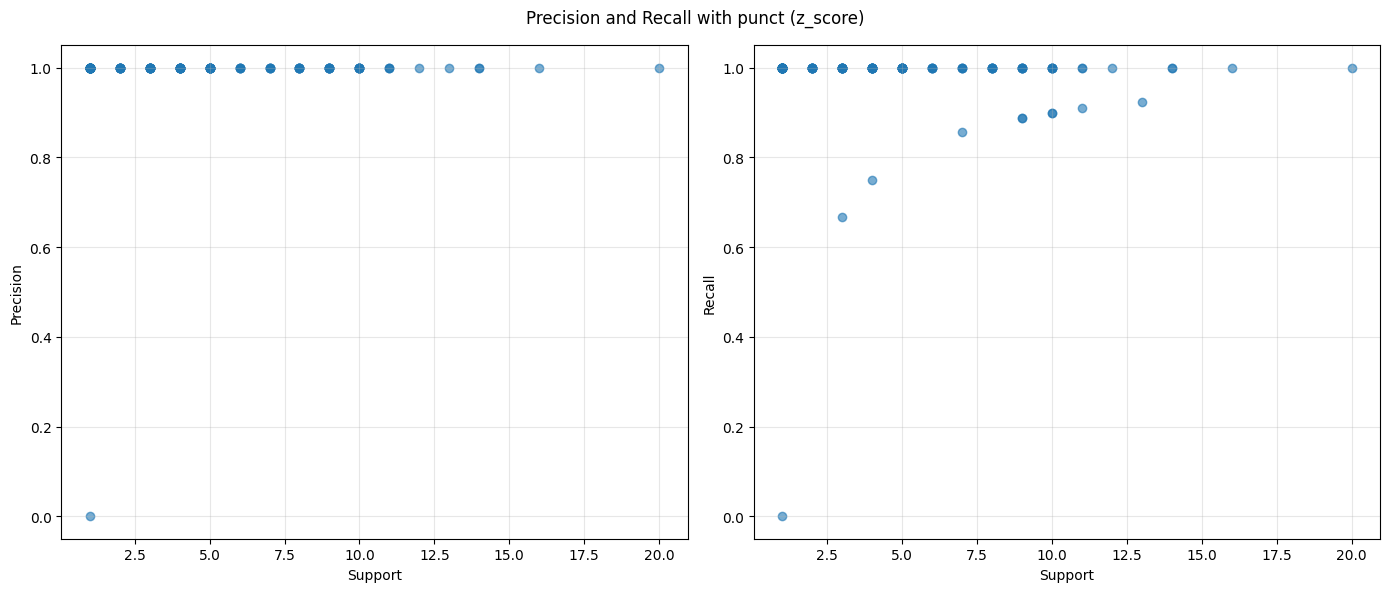

In [88]:
get_visual_quality(author_quality_z_score, 'z_score')

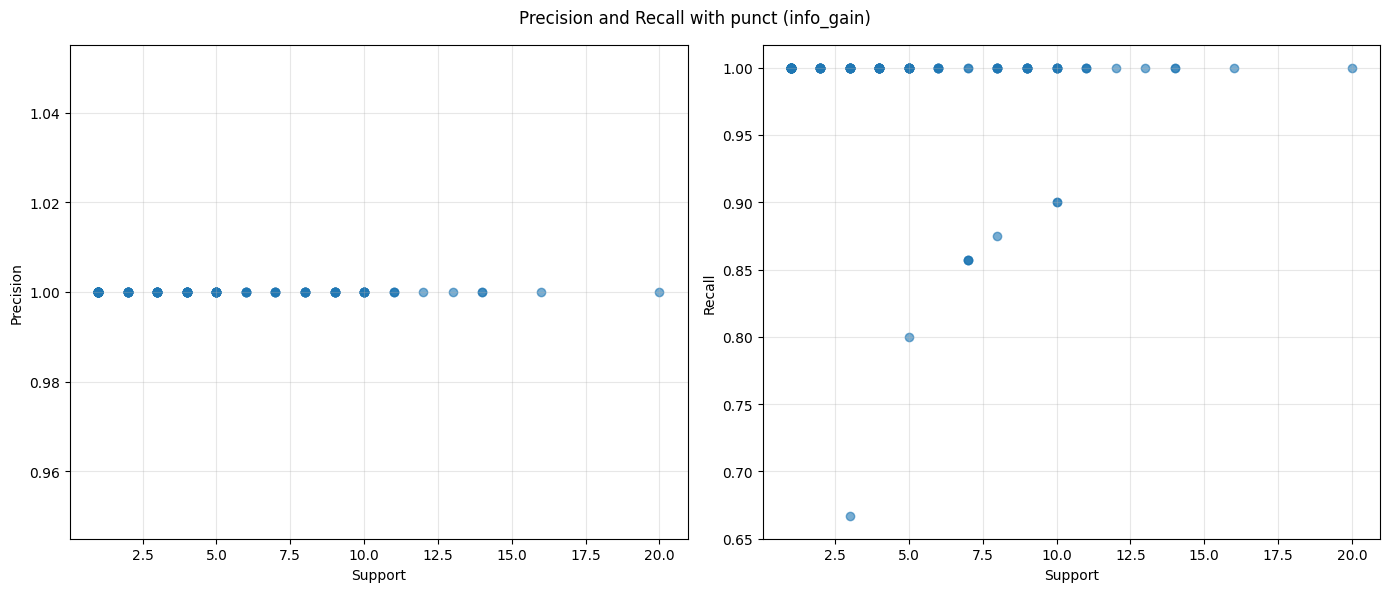

In [89]:
get_visual_quality(author_quality_info_gain, 'info_gain')

In [90]:
def visualize_authors_radar(df, selec_type):

    fig = go.Figure()

    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

    for i, row in df.iterrows():
        author = row['author']
        features = row['features']
        info_gain = row[selec_type]
        feature_names = row['feature_names']
        feature_stats = row['feature_stats']

        min_length = min(len(info_gain), len(feature_names), len(features))
        features = features[:min_length]
        info_gain = info_gain[:min_length]
        feature_names = feature_names[:min_length]

        values = np.abs(info_gain)

        custom_hover_data = []
        for feature_idx, feature_stat, ig_value in zip(features, feature_stats, info_gain):
            frequency = feature_stat
            custom_hover_data.append(
                f"Freq: {frequency} | ID: {feature_idx} | IG: {ig_value:.6f}"
            )

        fig.add_trace(go.Scatterpolar(
            r=values,
            theta=feature_names,
            fill='toself',
            name=author,
            hovertemplate='<b>Author:</b> ' + author + '<br>' +
                         '<b>Feature:</b> %{theta}<br>' +
                         '<b>Info Gain:</b> %{r:.6f}<br>' +
                         '<b>Details:</b> %{customdata}<br>' +
                         '<extra></extra>',
            customdata=custom_hover_data,
            line=dict(color=colors[i % len(colors)]),
            opacity=0.7
        ))

    max_val = 0
    for _, row in df.iterrows():
        if len(row['information_gain']) > 0:
            max_val = max(max_val, max(np.abs(row['information_gain'])))

    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, max_val * 1.1] if max_val > 0 else [0, 1]
            )
        ),
        title=dict(
            text=str(list(df['authors'])),
            x=0.5,
            xanchor='center'
        ),
        showlegend=True,
        width=800,
        height=600
    )

    fig.show()

In [91]:
def dendrogram_with_heatmap(author_topfeats, selec_type, n_top_features=100):
    from scipy.spatial.distance import pdist, squareform
    from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list

    author_vectors = []
    valid_authors = []

    for author_id, author_name in zip(author_ids, author_names):
        top_feats_list = author_topfeats[author_topfeats['author'] == author_name]['features'].values[0]

        top_feats = top_feats_list[:n_top_features]

        author_books_mask = books_author_id_np == author_id

        author_books_vectors = books_vect_np[author_books_mask][:, top_feats]
        author_mean_vector = np.mean(author_books_vectors, axis=0)
        author_vectors.append(author_mean_vector)
        valid_authors.append(author_name)

    X = np.array(author_vectors)

    distance_matrix = pdist(X, metric='euclidean')
    distance_square = squareform(distance_matrix)

    linkage_matrix = linkage(X, method='ward', metric='euclidean')

    fig = plt.figure(figsize=(14, 22))

    ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
    dendrogram(linkage_matrix,
               labels=valid_authors,
               ax=ax1,
               leaf_rotation=90,
               leaf_font_size=9,
               orientation='top')
    ax1.set_title(f'Дендрограмма авторов ({selec_type})', fontsize=12)
    ax1.set_ylabel('Расстояние')

    ax2 = plt.subplot2grid((2, 2), (1, 0), colspan=2, rowspan=2)

    order = leaves_list(linkage_matrix)

    ordered_distance = distance_square[np.ix_(order, order)]
    ordered_labels = [valid_authors[i] for i in order]

    im = ax2.imshow(ordered_distance, cmap='viridis', aspect='auto')
    ax2.set_xticks(range(len(ordered_labels)))
    ax2.set_yticks(range(len(ordered_labels)))
    ax2.set_xticklabels(ordered_labels, rotation=90, fontsize=8)
    ax2.set_yticklabels(ordered_labels, fontsize=8)
    ax2.set_title(f'Матрица расстояний между авторами ({selec_type})', fontsize=12)

    plt.colorbar(im, ax=ax2, label='Евклидово расстояние')

    plt.tight_layout()
    plt.show()

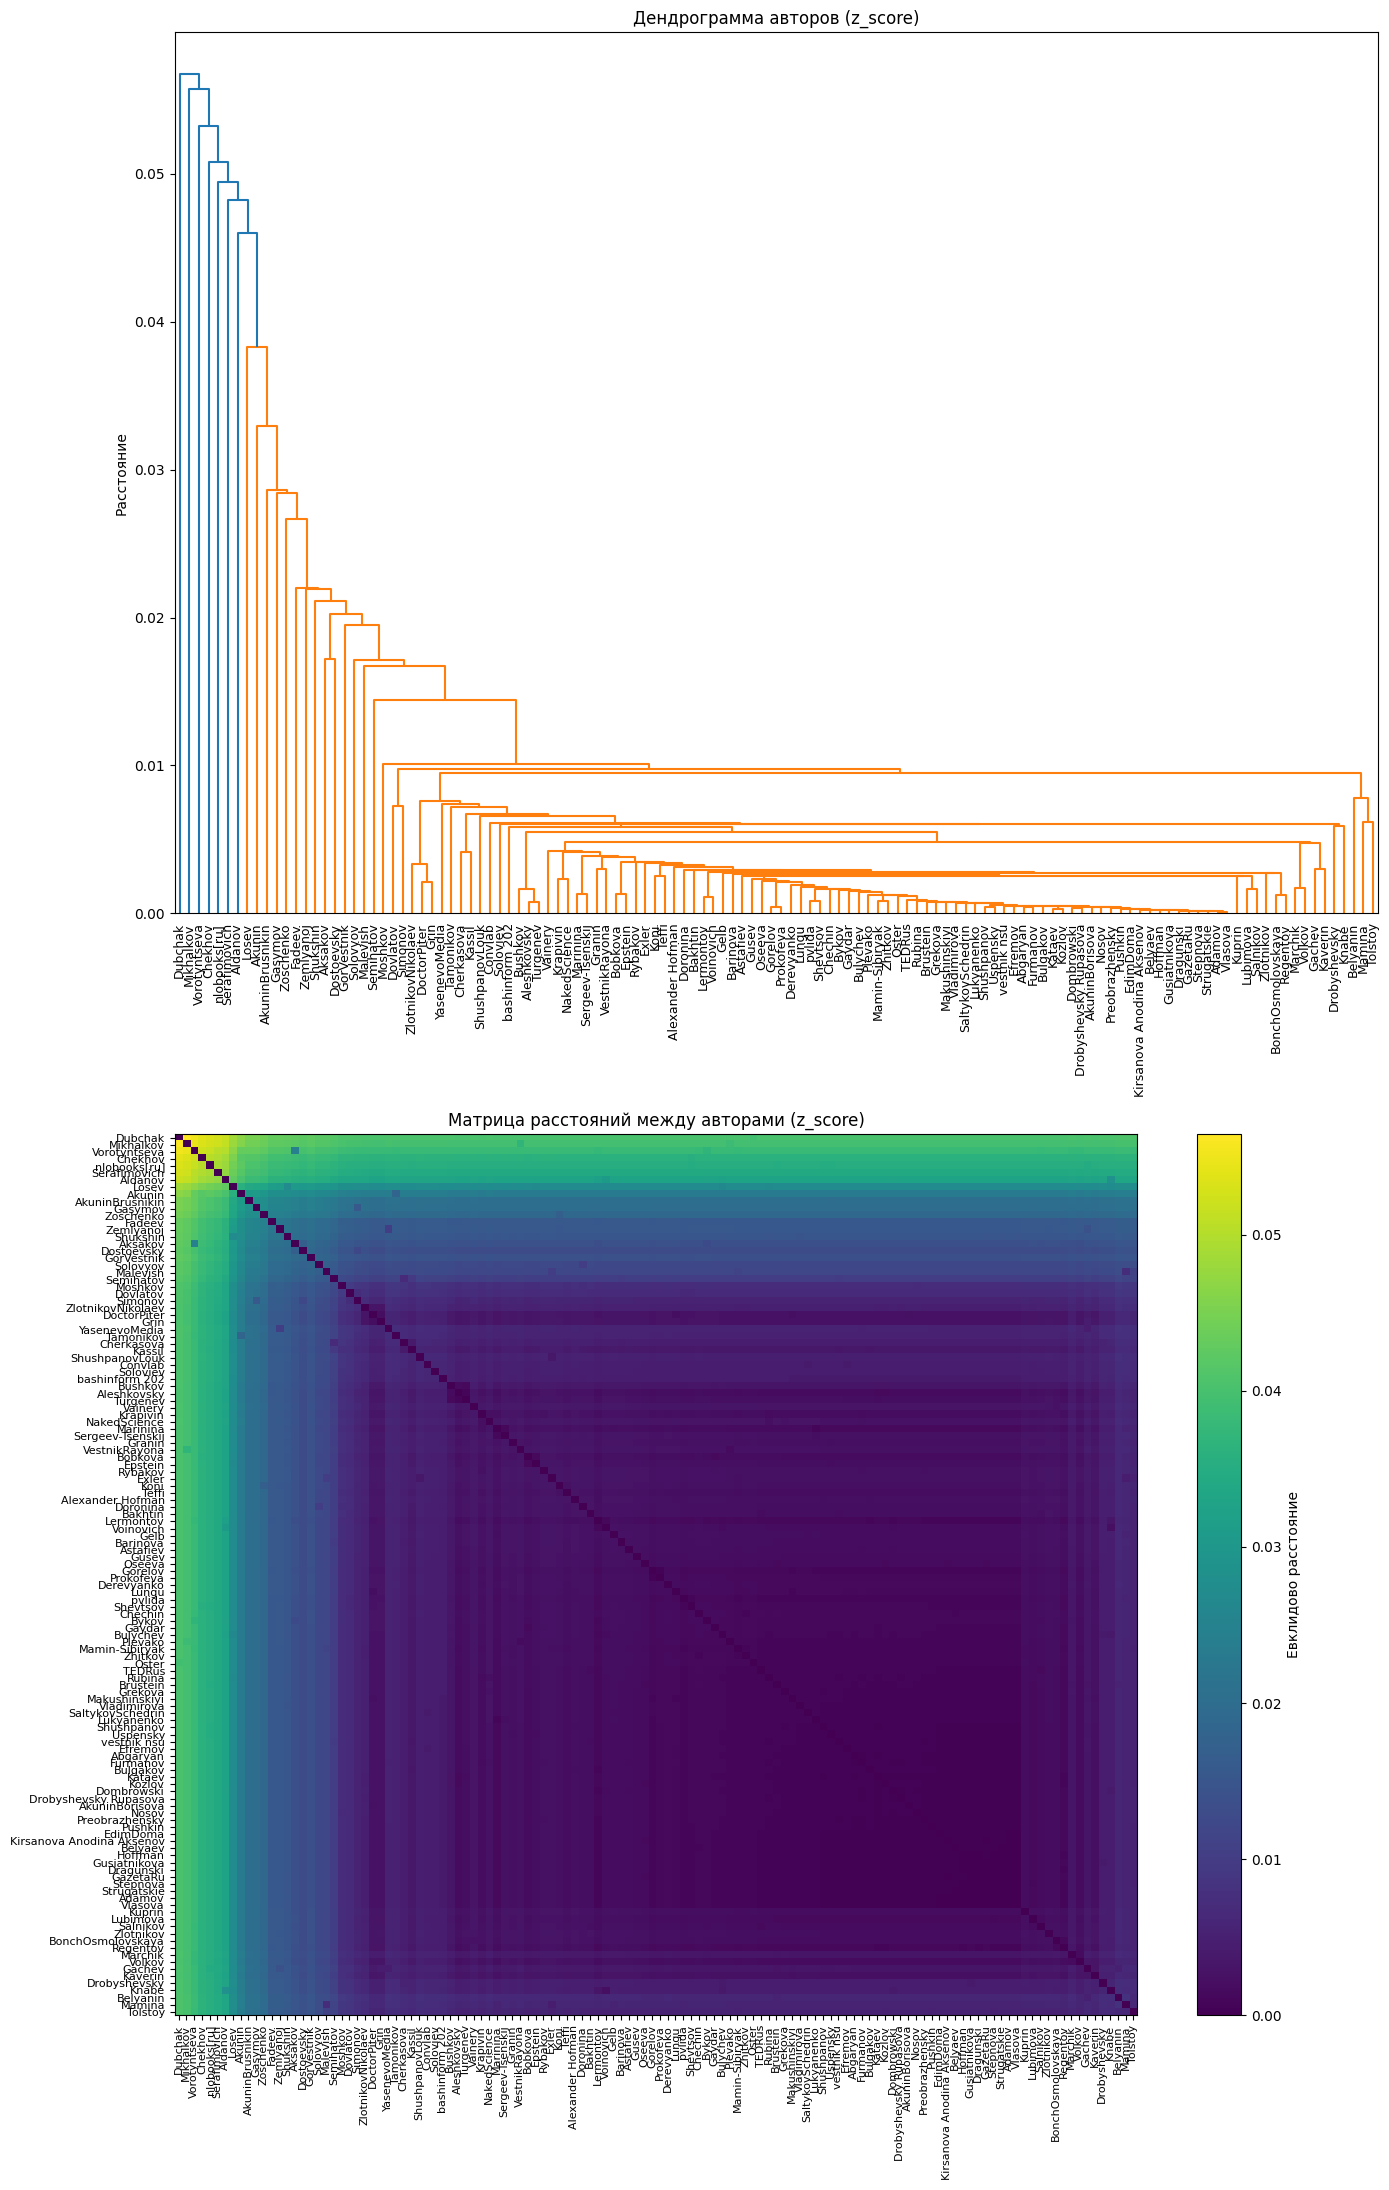

In [59]:
dendrogram_with_heatmap(z_score_top_feats, 'z_score')

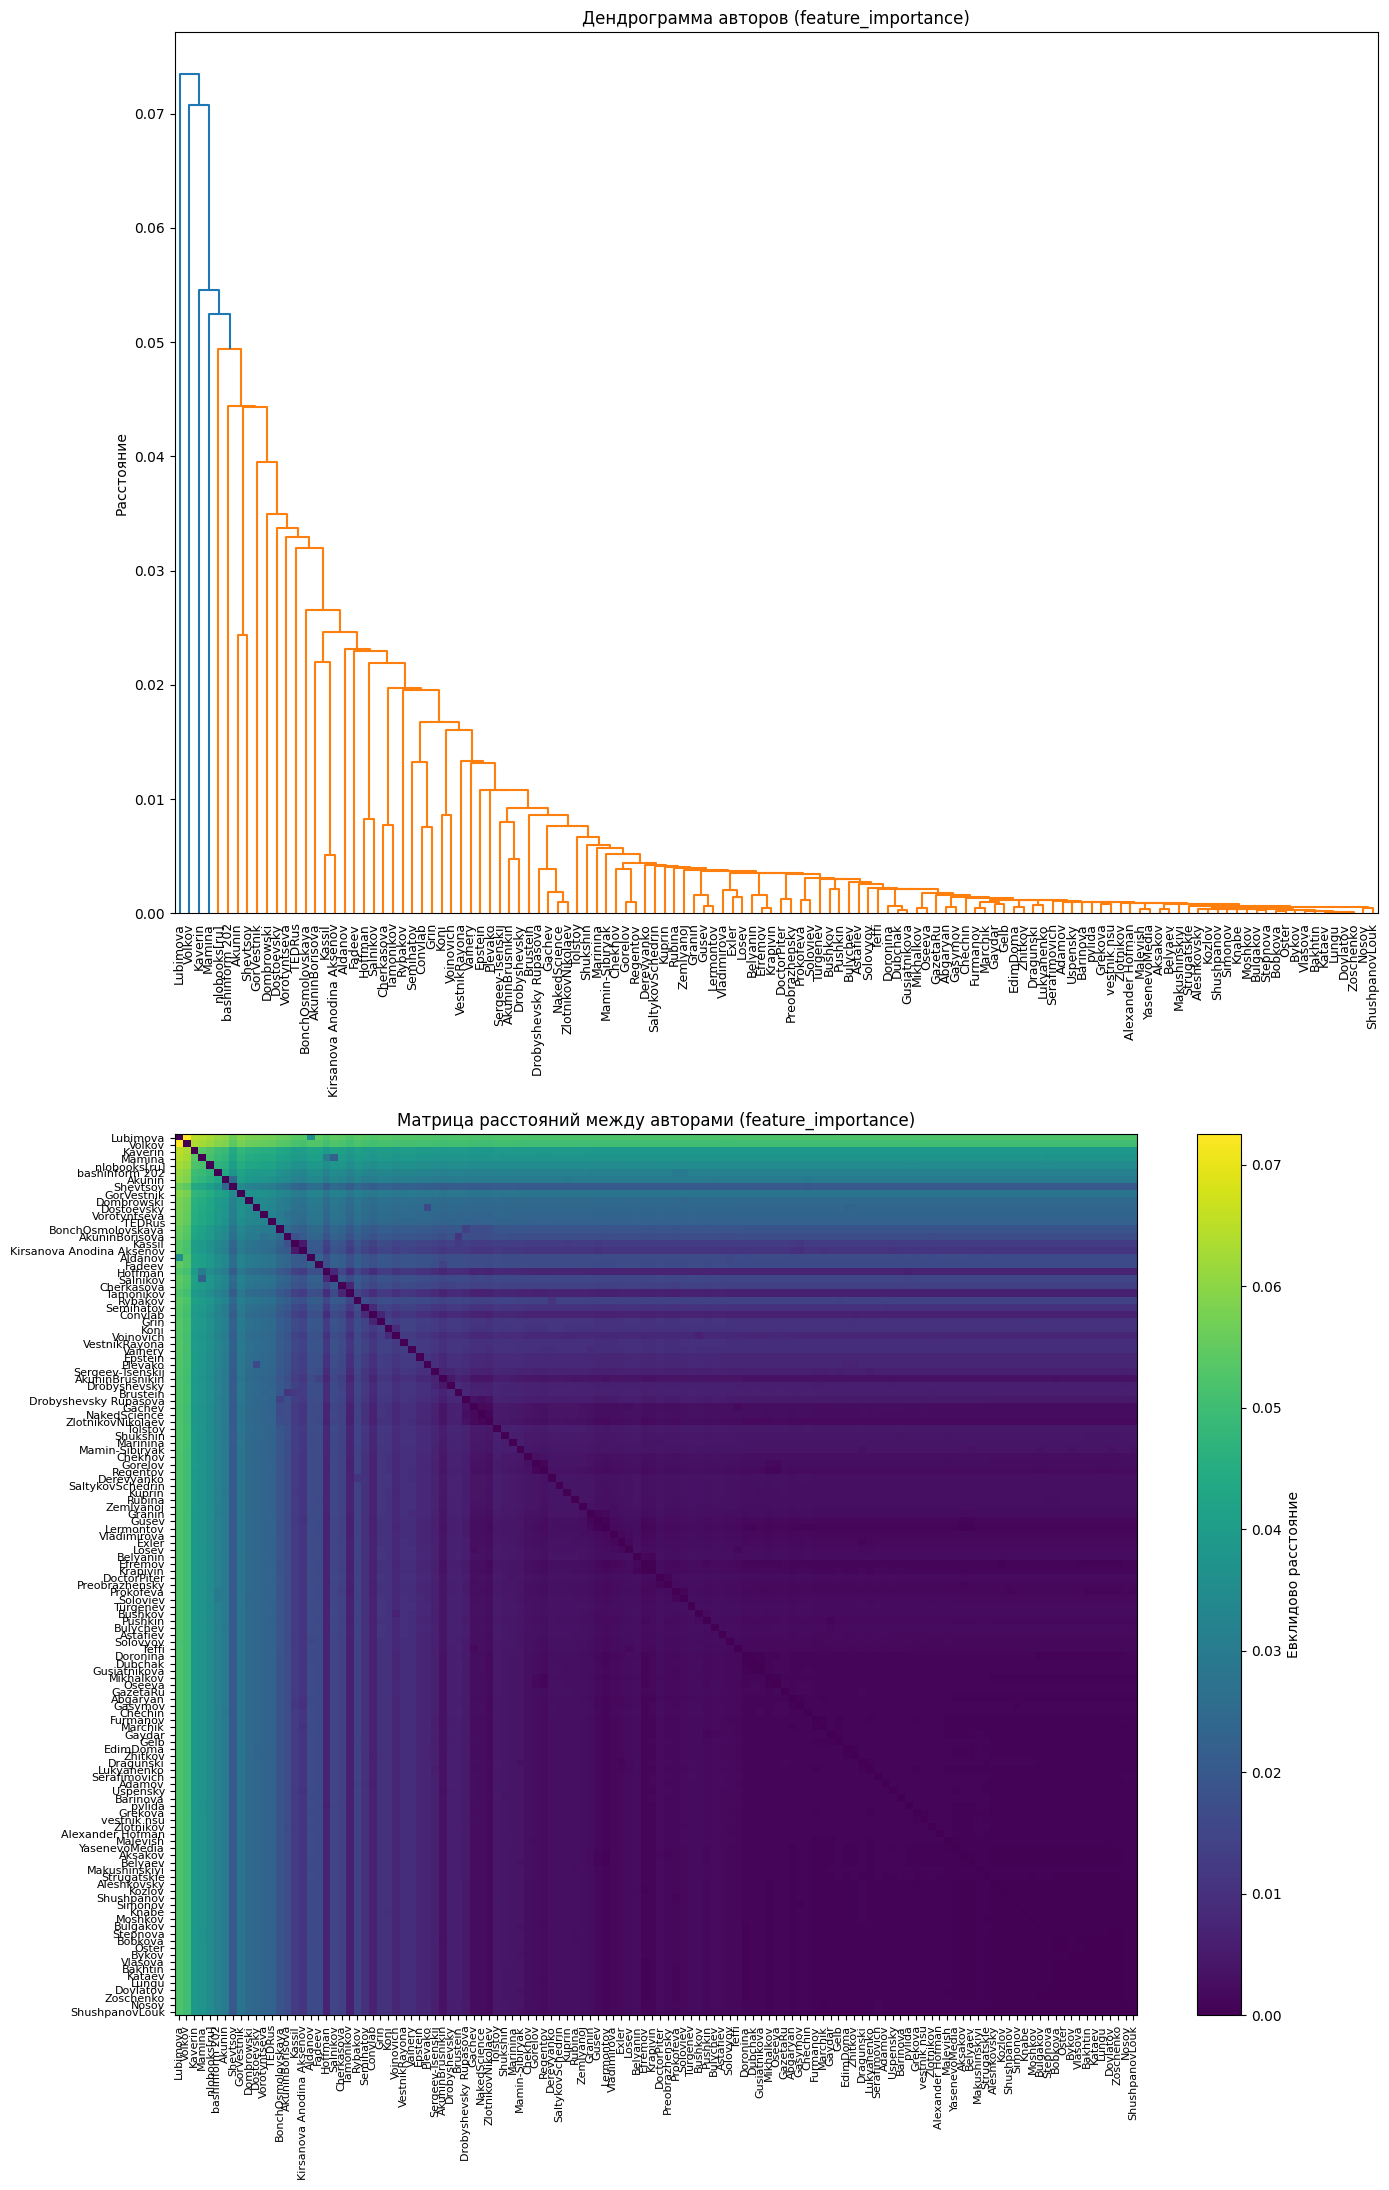

In [60]:
dendrogram_with_heatmap(feature_importance_top_feats, 'feature_importance')

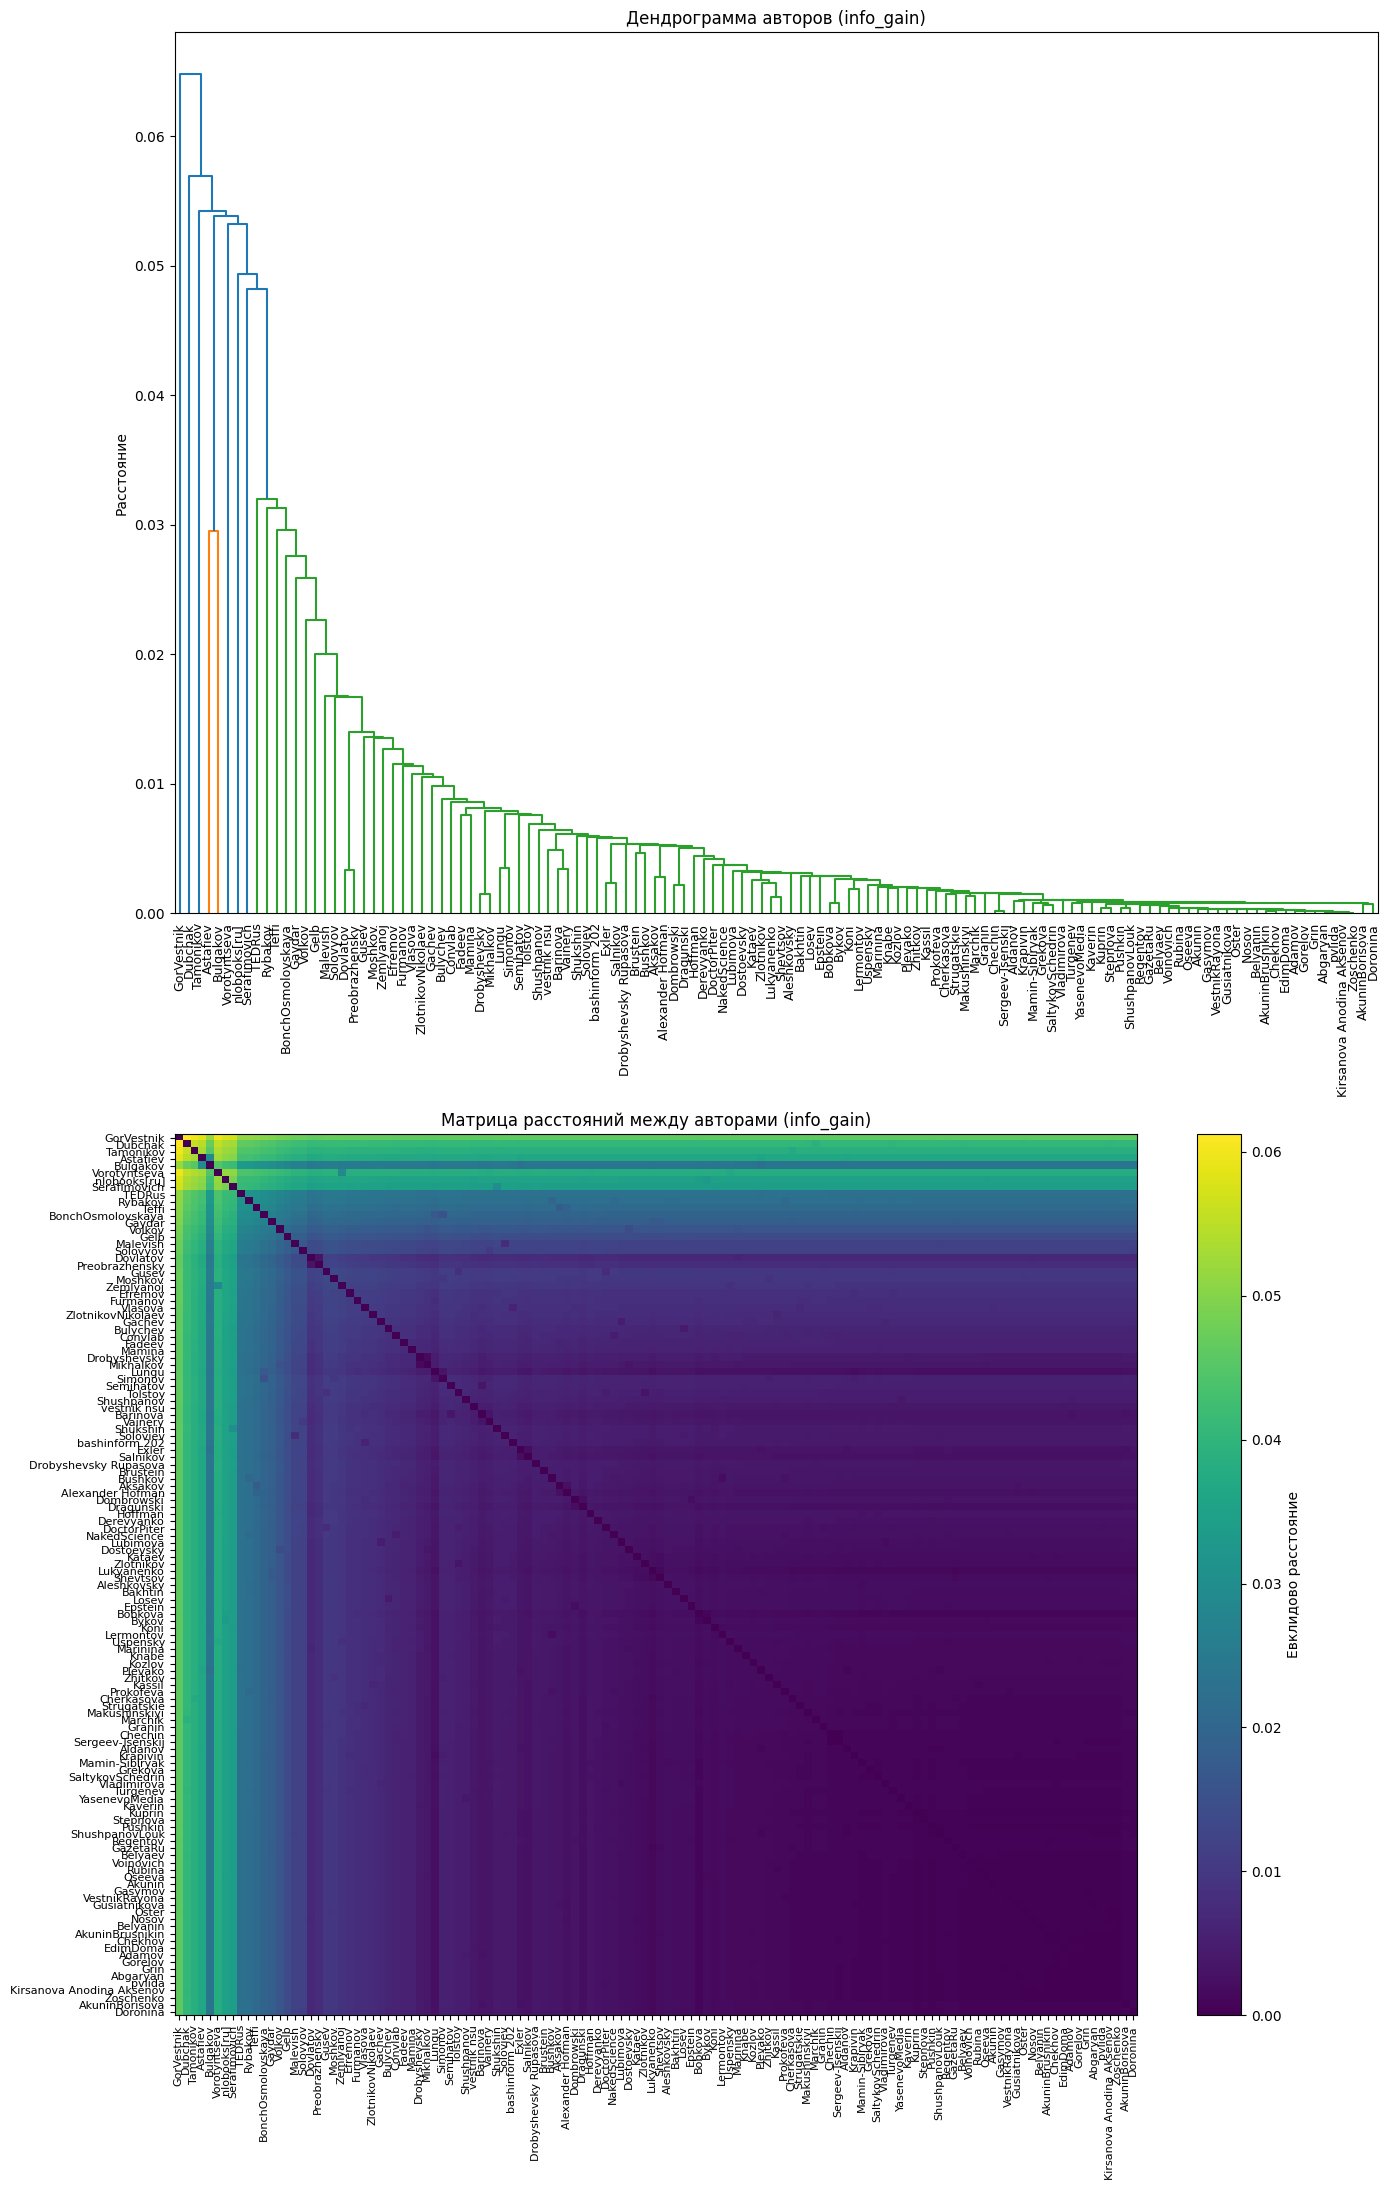

In [61]:
dendrogram_with_heatmap(info_gain_top_feats, 'info_gain')

In [62]:
import umap
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def visualize_author_vectors_umap(author_topfeats, selec_type, n_top_features=100):
    """
    UMAP визуализация с matplotlib
    """
    author_vectors = []
    valid_authors = []

    for author_id, author_name in zip(author_ids, author_names):
        top_feats_list = author_topfeats[author_topfeats['author'] == author_name]['features'].values[0]
        top_feats = top_feats_list[:n_top_features]

        author_books_mask = books_author_id_np == author_id
        author_books_vectors = books_vect_np[author_books_mask][:, top_feats]
        author_mean_vector = np.mean(author_books_vectors, axis=0)
        author_vectors.append(author_mean_vector)
        valid_authors.append(author_name)

    X = np.array(author_vectors)

    reducer = umap.UMAP(
        n_neighbors=min(15, len(X) - 1),
        min_dist=0.1,
        n_components=2,
        random_state=42,
        metric='cosine'
    )

    embedding = reducer.fit_transform(X)

    plt.figure(figsize=(12, 10))

    scatter = plt.scatter(embedding[:, 0], embedding[:, 1],
                         c=range(len(valid_authors)),
                         cmap='viridis',
                         s=100,
                         alpha=0.7)

    for i, author in enumerate(valid_authors):
        plt.annotate(author, (embedding[i, 0], embedding[i, 1]),
                    fontsize=9, alpha=0.8, xytext=(5, 5),
                    textcoords='offset points')

    plt.title(f'UMAP Projection of Authors ({selec_type})', fontsize=14)
    plt.xlabel('UMAP Dimension 1', fontsize=12)
    plt.ylabel('UMAP Dimension 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


d:\Uni\diplom_experiments\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


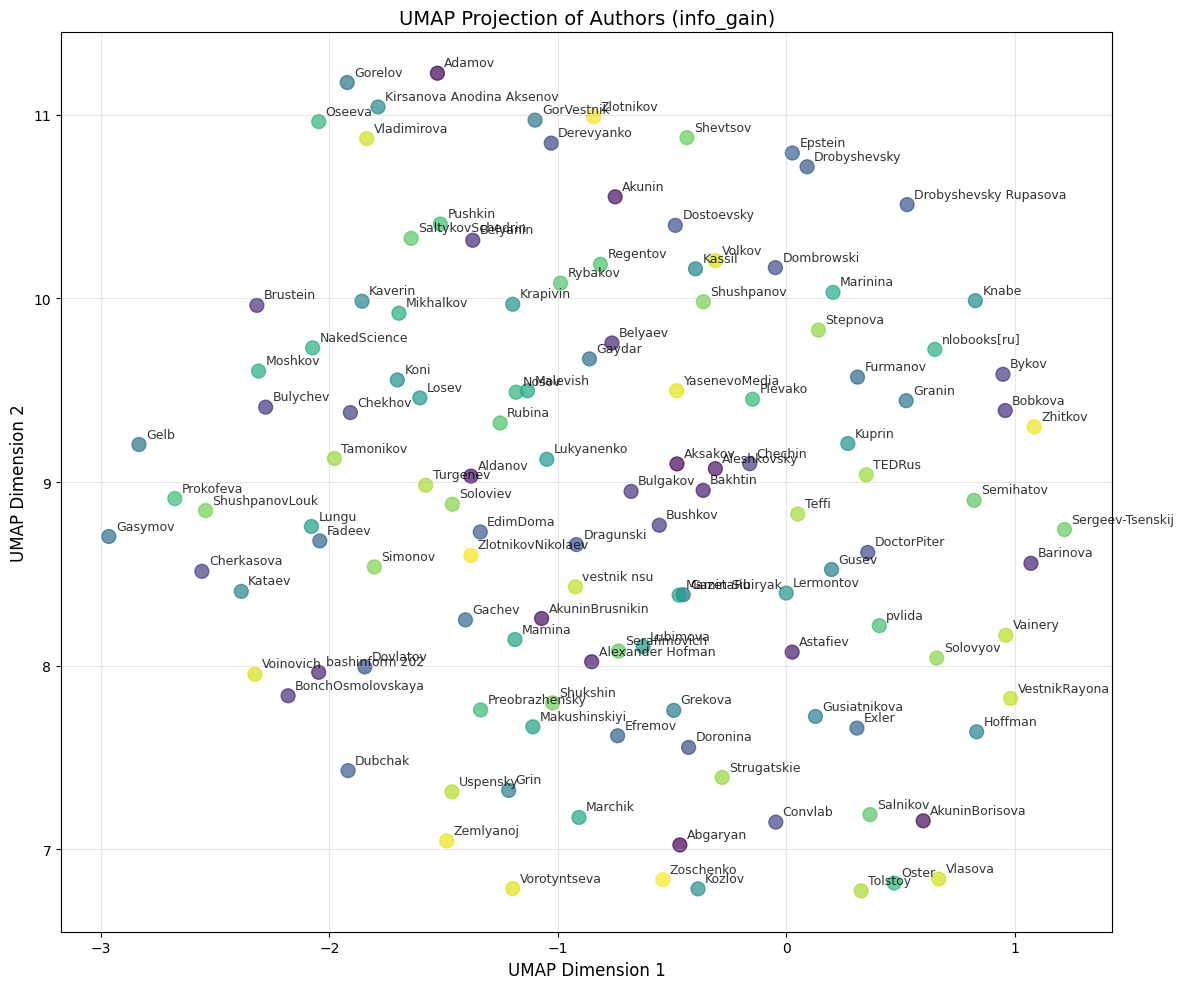

In [63]:
visualize_author_vectors_umap(info_gain_top_feats, 'info_gain', 500)

d:\Uni\diplom_experiments\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


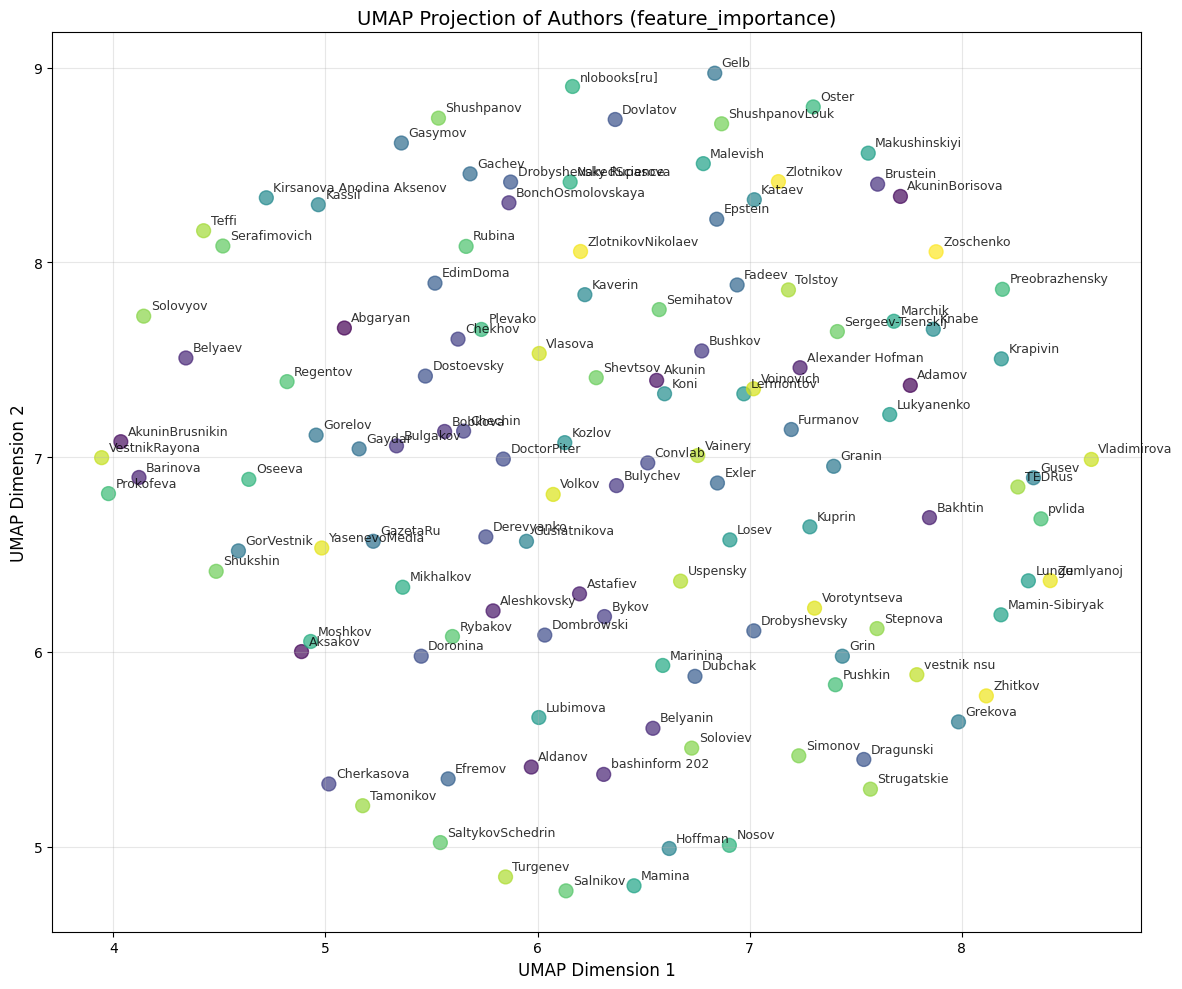

In [64]:
visualize_author_vectors_umap(feature_importance_top_feats, 'feature_importance', 500)

d:\Uni\diplom_experiments\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


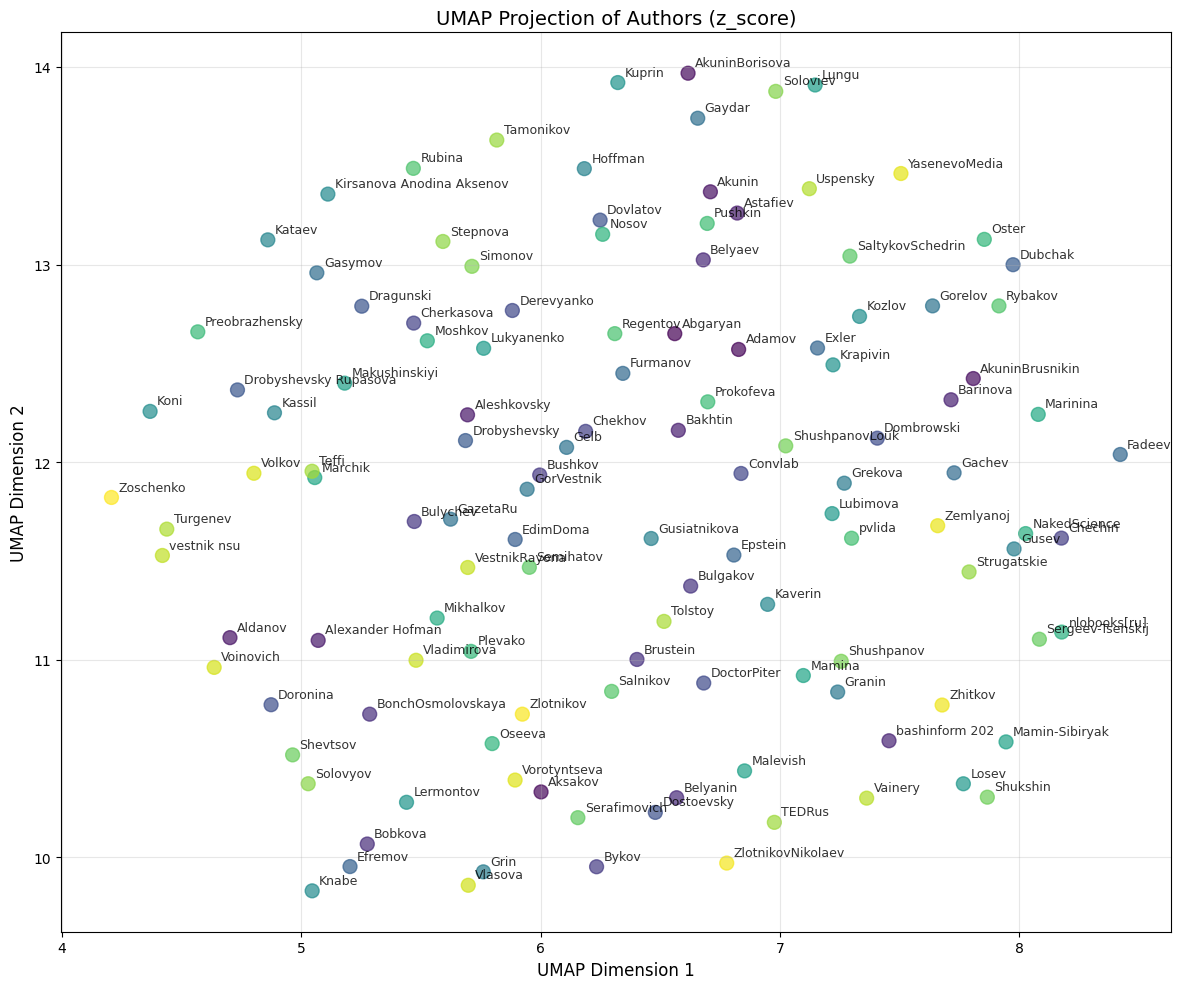

In [65]:
visualize_author_vectors_umap(z_score_top_feats, 'z_score', 500)